In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
import os
import networkx as nx
import igraph as ig
import leidenalg as la
import glob

In [10]:
# choose basa or GG
database = 'GG' # 'basa' or 'GG'

def get_functional_categories(database):
    if database == 'basa':
        basa_groups = pd.read_csv('./data/basa/basa_groups.csv')
        # make a community_int column with integers from 0 to number of unique communities - 1
        basa_groups['Community_int'] = basa_groups['Community'].astype('category').cat.codes
        basa_partition = basa_groups.set_index('Taxa').to_dict()['Community_int']

        basa_community_index = basa_groups.set_index('Community').to_dict()['Community_int']
        basa_community_index_T = {v: k for k, v in basa_community_index.items()}

        return basa_partition, basa_community_index, basa_community_index_T

    if database == 'GG':
        GG_groups = pd.read_csv('./data/GG/gg_groups.csv')
        GG_groups['Community_int'] = GG_groups['Community'].astype('category').cat.codes
        GG_partition = GG_groups.set_index('Taxa').to_dict()['Community_int']
        GG_community_index = GG_groups.set_index('Community').to_dict()['Community_int']
        GG_community_index_T = {v: k for k, v in GG_community_index.items()}

        return GG_partition, GG_community_index, GG_community_index_T

    if database == 'moossee':
        moossee_groups = pd.read_csv('./data/moossee/groups_moossee.csv')
        moossee_groups['Community_int'] = moossee_groups['Community'].astype('category').cat.codes
        moossee_partition = moossee_groups.set_index('Taxa').to_dict()['Community_int']
        moossee_community_index = moossee_groups.set_index('Community').to_dict()['Community_int']
        moossee_community_index_T = {v: k for k, v in moossee_community_index.items()}

        return moossee_partition, moossee_community_index, moossee_community_index_T
    
    if database == 'Burgäschisee':
        Burgäschisee_groups = pd.read_csv('./data/Burgäschisee/groups_Burgäschisee.csv')
        Burgäschisee_groups['Community_int'] = Burgäschisee_groups['Community'].astype('category').cat.codes
        Burgäschisee_partition = Burgäschisee_groups.set_index('Taxa').to_dict()['Community_int']
        Burgäschisee_community_index = Burgäschisee_groups.set_index('Community').to_dict()['Community_int']
        Burgäschisee_community_index_T = {v: k for k, v in Burgäschisee_community_index.items()}

        return Burgäschisee_partition, Burgäschisee_community_index, Burgäschisee_community_index_T
    
if database == 'basa':
    results = 'results/basa'
    data_species = './GAM_species/basa/species_fit_140_0.01.pkl'
    windows = [(0, 40), (20, 60), (40, 80), (60, 100), (80, 120), (100, 140)]
    windows = [(0, 51), (52, 85), (85, 140)]
    windows = [(0, 51)]
    windows = [(0, 51), (51, 85), (85, 140)]

if database == 'GG':
    results = 'results/GG'
    data_species = './GAM_species/GG/species_fit_300_0.01.pkl'
    windows = [(0, 100), (50, 150), (100, 200), (150, 250), (200, 300)]
    windows = [(150, 199), (200, 249)]
    windows = [(0, 56)]
    windows = [(0, 56), (57, 149), (150, 249), (250, 300)]
    windows = [(0, 57), (57, 150), (150, 250), (250, 300)]

if database == 'moossee':
    results = 'results/moossee'
    data_species = './GAM_species/moossee/species_fit_815_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 149), (149, 380), (380, 644), (644, 815)]

if database == 'Burgäschisee':
    results = 'results/Burgäschisee'
    data_species = './GAM_species/Burgäschisee/species_fit_723_0.01.pkl'
    windows = [(0, 149)]
    windows = [(0, 180), (180, 465), (465, 723)]

species_index = pd.read_pickle(f'./GAM_species/{database}/species_index.pkl')
species_index_T = pd.Series(species_index)
species_index_T = pd.Series(species_index_T.index, index = species_index_T.values)
species_index_T = species_index_T.to_dict()

if database == 'basa':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'GG':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'moossee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())
if database == 'Burgäschisee':
    species_index_non_aq = {k: v for k, v in species_index.items()}
    species_index_T_non_aq = {v: k for k, v in species_index_non_aq.items()}
    non_aq_species = list(species_index_non_aq.keys())

abundances = pd.read_pickle(data_species)

custom_partition, custom_community_index, custom_community_index_T = get_functional_categories(database)

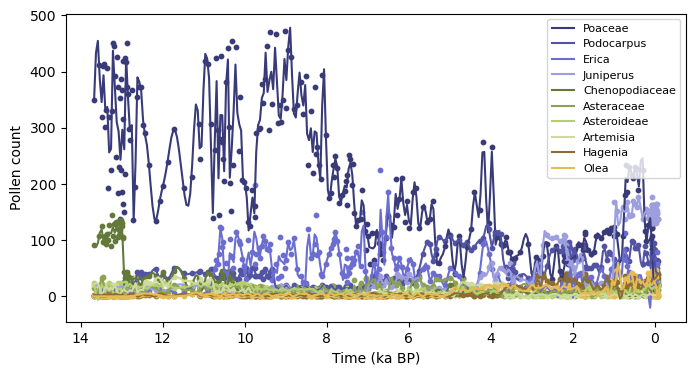

In [11]:
# plot the 10 species (all in the same axes) with highest total abundance over time
abundances_species = pd.DataFrame({k: v['y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})

prev_abundances_species = pd.DataFrame({k: v['prev_y'] for k, v in abundances.items() if k in species_index_non_aq.keys()})
# sort by total abundance
abundances_species_sum = abundances_species.sum().sort_values(ascending=False)
top_10_species = abundances_species_sum.index[:10]

fig,ax = plt.subplots(figsize=(8, 4))

# get map
colors_sequence = plt.get_cmap('tab20b')(np.linspace(0, .5, len(top_10_species)))

for i,species in enumerate(top_10_species):
    ax.plot(-abundances[abundances.columns[1]]['x']/1000, abundances_species[species], color=colors_sequence[i], alpha=1, label=species)
    ax.scatter(-abundances[abundances.columns[1]]['prev_x']/1000, prev_abundances_species[species], color=colors_sequence[i], alpha=1, s=10)

# invert x axis
ax.invert_xaxis()
# ax.set_ylim(0,100)
ax.set_xlabel('Time (ka BP)')
ax.set_ylabel('Pollen count')
ax.legend(loc='upper right', fontsize=8)


In [12]:
import networkx as nx
def read_GC_network(causality_name):
    granger_causalities = []
    granger_causalities_p_values = []
    for idx,(start,end) in enumerate(windows):
        granger_causality = pd.read_pickle(f'{results}/{causality_name}/original_table_{start}-{end}.pkl')
        granger_causalities.append(granger_causality)

        granger_causality_p_values = pd.read_pickle(f'{results}/{causality_name}/bootstrapped_p_values_{start}-{end}.pkl')
        granger_causality_p_values[np.eye(granger_causality_p_values.shape[0], dtype=bool)] = np.nan
        granger_causalities_p_values.append(granger_causality_p_values)
    graphs = []

    for idx,(start,end) in enumerate(windows):
        
        # for the TE p_values (p_values_list) or the gc p_values (granger_causalities_p_values)
        # adjacency = p_values_list[idx]
        adjacency = granger_causalities_p_values[idx]
        # remove na from the numpy array adjacency
        adjacency = np.nan_to_num(adjacency, nan=1.0)
        # ONLY NON AQUATIC SPECIES
        species_list = list(species_index_T_non_aq.keys())

        # adjacency_non_aq = adjacency[np.ix_(species_list, species_list)]
        # cut_value = np.sort(adjacency_non_aq.flatten())[L]

        cut_value = 0.05

        adjacency_pvalued = (adjacency <= cut_value).astype(int)
        adjacency = granger_causalities[idx] * adjacency_pvalued


        graph = nx.from_numpy_array(adjacency, create_using=nx.DiGraph, edge_attr='weight')
        # remove all nodes that are not in the non_aq_species list
        graph.remove_nodes_from([node for node in graph.nodes() if species_index_T[node] not in non_aq_species])


        valid_species = 0
        invalid_species_list = []
        pollen_threshold = 0.5 # if the series have less than 3 values above 0.5, we consider it as not present, and we remove the links to and from that species
        
        for node in graph.copy().nodes():
            species_name = species_index_T[node]
            if (abundances[species_name]['y'][start : end] > pollen_threshold).sum() < 2.5:
                
                # set granger_causalities to 0 and granger_causalities_p_values to 1
                granger_causalities[idx][:, node] = 0
                granger_causalities[idx][node, :] = 0
                granger_causalities_p_values[idx][:, node] = 1
                granger_causalities_p_values[idx][node, :] = 1

                graph.remove_node(node)
                invalid_species_list.append(species_name)

            else:
                valid_species = valid_species + 1

        print("Invalid species in window ", start, end, ": ", len(invalid_species_list))
        print("Invalid species in window ", start, end, ": ", invalid_species_list)
        print("Valid species in window ", start, end, ": ", valid_species)
        
        graphs.append(graph)
        print(cut_value, graph.number_of_edges())
        # currently it's just set to cut a certain value (p=0.05), so it's simple

    return granger_causalities, granger_causalities_p_values, graphs

In [13]:
def read_bootstrap_GC_networks(causality_name):
    bootstrap_dir = f'{results}/{causality_name}'

    original_table = []
    bootstrapped_p_values = []

    for idx,(start,end) in enumerate(windows):
        try:
            original_table.append(pd.read_pickle(f'{bootstrap_dir}/original_table_{start}-{end}.pkl'))
        except:
            print(f'No original p-values for window {start}-{end}')
        print('Loading table')
        bootstrapped_p_values.append(np.zeros(original_table[0].shape))

        # get every bootstrap table for this window -> pattern is for example /table_0-50_bs*.pkl
        pattern = f'{bootstrap_dir}/bootstrap_tables/table_{start}-{end}_bs*.pkl'
        bootstrap_files = glob.glob(pattern)
        nbootstraps = len(bootstrap_files)
        print('Number of bootstraps: ', nbootstraps)
        # for b in range(nbootstraps):

        prob_lower = np.zeros(original_table[idx].shape)
        prob_higher = np.zeros(original_table[idx].shape)

        for bootstrap_file in bootstrap_files:
            try:
                bootstrap_table = pd.read_pickle(bootstrap_file)
            except:
                print('Error reading bootstrap file: ', bootstrap_file)

            # now we compare original_table and one bootstrap_table. for every element in the matrix
            # if original_p_values[i,j] > 0, then we count the bootstrap_table[i,j] >= original_p_values[i,j]
            # if original_p_values[i,j] < 0, then we count the bootstrap_table[i,j] <= original_p_values[i,j]
            
            prob_lower += (bootstrap_table < original_table[idx]).astype(int)
            prob_higher += (bootstrap_table > original_table[idx]).astype(int)

            #_______________________________________________________________
            # bootstrapped_p_values[idx] += 2 * ((bootstrap_table >= original_table[idx]) * (original_table[idx] >= average_bootstrap_table) + (bootstrap_table <= original_table[idx]) * (original_table[idx] < average_bootstrap_table)).astype(int)
            bootstrapped_p_values[idx] += (np.abs(bootstrap_table) >= np.abs(original_table[idx])).astype(int)
            # THESE ASSUME A SYMMETRIC DISTRIBUTION (or short tailed), WHICH MAY NOT BE THE CASE
            #_______________________________________________________________
            # print('Time adding values: ', time() - time_start, ' s')

        bootstrapped_p_values[idx] = bootstrapped_p_values[idx] / nbootstraps

        # bootstrapped_p_values[idx] = 2 * np.minimum(prob_lower, prob_higher) / nbootstraps
        
        # write the p-values to a file
        pd.to_pickle(bootstrapped_p_values[idx], f'{bootstrap_dir}/bootstrapped_p_values_{start}-{end}.pkl')
    return original_table, bootstrapped_p_values

In [14]:
# read database's original network

causality_dir = 'bootstrap_conditional_GC_OLS'
lag = '_lag1'
cond = f'abundances_cond1{lag}'
# read_bootstrap_GC_networks(f'{causality_dir}/{cond}')
granger_causalities, granger_causalities_p_values, graphs = read_GC_network(f'{causality_dir}/{cond}')

Invalid species in window  0 57 :  40
Invalid species in window  0 57 :  ['Carduus', 'Polygonum', 'Tribulus', 'Hypericum', 'Myrsine', 'Rosa', 'Schefflera', 'Brucea', 'Iridaceae', 'Maytenus', 'Buxus', 'Psydrax', 'Celastraceae', 'Celtis', 'Ekebergia', 'Clematis', 'Allophylus', 'Commiphora', 'Cussonia', 'Dobera', 'Lannea', 'Macaranga', 'Jasminum', 'Rhus', 'Securinega', 'Teclea', 'Zanthoxylum', 'Euphorbia', 'Euphorbiacea', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Urticaceae', 'Ricinus']
Valid species in window  0 57 :  42
0.05 70
Invalid species in window  57 150 :  21
Invalid species in window  57 150 :  ['Carduus', 'Polygonum', 'Rosa', 'Brucea', 'Buxus', 'Psydrax', 'Celastraceae', 'Ekebergia', 'Allophylus', 'Cussonia', 'Macaranga', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Ricinus']
Valid species in window  57 150 :  61
0.05 111
Invalid spec

In [15]:
# SENSITIVITY

deviations = np.logspace(-2, np.log10(1), num=10)

# read table without deviations

causality_dir = 'nullmodel'
cond = f'cond2'

pattern = f'results/{database}/{causality_dir}/{cond}/network_j*'
network_dirs = glob.glob(pattern)
network_dirs = [network_dir.removeprefix(f'results/{database}') for network_dir in network_dirs]
n_networks = len(network_dirs)

networks = []
for j, network_dir in enumerate(network_dirs):
    j_suffix = int(network_dir.removeprefix(f'/{causality_dir}/{cond}/network_j'))
    if j_suffix > 123:
        continue
    print(f'Reading network {j_suffix}')
    read_bootstrap_GC_networks(f'{network_dir}')
    gc_result, granger_causalities_p_values_count, graph_result = read_GC_network(network_dir)
    networks.append(graph_result)

Reading network 31
Loading table
Number of bootstraps:  1000
Loading table
Number of bootstraps:  1000
Loading table
Number of bootstraps:  1000
Loading table
Number of bootstraps:  1000
Invalid species in window  0 57 :  40
Invalid species in window  0 57 :  ['Carduus', 'Polygonum', 'Tribulus', 'Hypericum', 'Myrsine', 'Rosa', 'Schefflera', 'Brucea', 'Iridaceae', 'Maytenus', 'Buxus', 'Psydrax', 'Celastraceae', 'Celtis', 'Ekebergia', 'Clematis', 'Allophylus', 'Commiphora', 'Cussonia', 'Dobera', 'Lannea', 'Macaranga', 'Jasminum', 'Rhus', 'Securinega', 'Teclea', 'Zanthoxylum', 'Euphorbia', 'Euphorbiacea', 'Phyllantus', 'Tamarindus', 'Alchornea', 'Asphodellus', 'Cerealia', 'Plantago', 'Planceolata', 'Rumex', 'Solanum', 'Urticaceae', 'Ricinus']
Valid species in window  0 57 :  42
0.05 54
Invalid species in window  57 150 :  21
Invalid species in window  57 150 :  ['Carduus', 'Polygonum', 'Rosa', 'Brucea', 'Buxus', 'Psydrax', 'Celastraceae', 'Ekebergia', 'Allophylus', 'Cussonia', 'Macaranga'

In [20]:
i

3

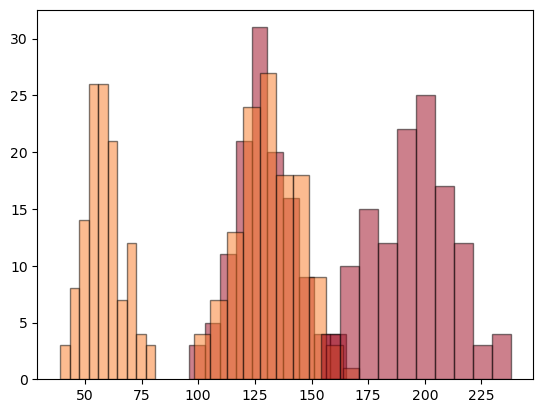

In [21]:
# each graphs is a list of len(windows) graphs
if database == 'basa':
    fire_colors = ["#9b031a","#FB990E","#e35412"]
elif database == 'GG':
    fire_colors = ['#fb7923', '#9b031a', '#fb7923', '#9b031a']
elif database == 'moossee':
    fire_colors = ['orange', 'red', 'orange', 'red']
elif database == 'Burgäschisee':
    fire_colors = ['red', 'pink', 'red']

nlinks = np.zeros((len(networks), len(windows)))
fire = np.zeros((len(networks),len(windows)))
for id_graphs,graphs in enumerate(networks):
    for idx, graph in enumerate(graphs):
        nlinks[id_graphs, idx] = len([e for e in graph.edges()])

        fire_percent = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
        fire[id_graphs, idx]= fire_percent

nlinks_avg = np.average(nlinks, axis=0)
nlinks_std = np.std(nlinks, axis=0)
fire_avg = np.average(fire, axis=0)
fire_std = np.std(fire, axis=0)

# plt.hist(fire[:,2])
for i in range(len(windows)):
    plt.hist(nlinks[:,i], alpha=0.5, edgecolor='black', color=fire_colors[i])


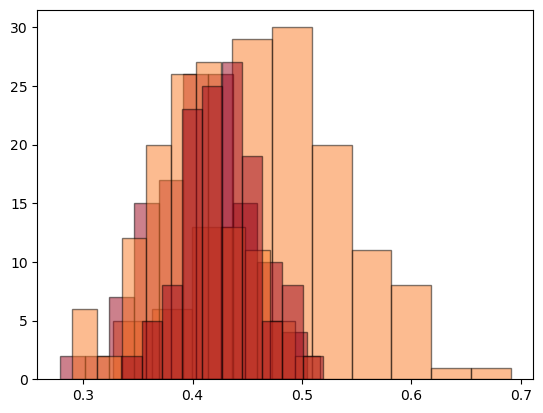

In [22]:
for i in range(len(windows)):
    plt.hist(fire[:,i], alpha=0.5, edgecolor='black', color=fire_colors[i])

In [43]:
# set functional group as node attribute

def set_functional_group_attribute(g):
    for node in g.nodes():
            species = species_index_T_non_aq[node]
            if species in custom_partition:
                g.nodes[node]['functional_group'] = custom_partition[species]
            else:
                g.nodes[node]['functional_group'] = -1
    return g


def sequential_custom_generator():
    colors_list = ['forestgreen', 'royalblue', 'crimson', 'grey', 'purple', 'orange']

    colors_list = ["#006ba6","#0281d3","#0496ff","#ffbc42","#f69248","#ec674e","#d81159","#8f2d56"] # reds and blues
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d"] # greens and yellows

    # for 9 colors instead of 8
    colors_list = ["#f6ad02","#dbb314","#a1a94a","#88a559","#6ea067","#449d4c","#199a31","#0d841d", "#0a662e"]

    index = 0
    # add randomness to which color we take each time (add a constant seed)
    np.random.seed(42)
    random_indices = np.random.permutation(len(colors_list))
    while True:
        yield mcolors.to_rgb(colors_list[index % len(colors_list)])
        index += 1

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from networkx.drawing.nx_pydot import pydot_layout
import matplotlib.colors as mcolors

from lib.halfarrowpatch import *


def arc3_circle_center(posA, posB, rad):
    A, B = np.array(posA), np.array(posB)
    M = (A + B) * 0.5
    d = B - A
    L = np.linalg.norm(d)
    n = np.array([-d[1], d[0]]) / L
    h = rad * L * 0.5
    R = (L**2 / 4 + h**2) / (2 * h)
    C = M + n * (R - L**2 / (8 * h))
    return C, R

def rotate_point(p, center, angle):
    s, c = np.sin(angle), np.cos(angle)
    v = p - center
    return center + np.array([c*v[0] - s*v[1], s*v[0] + c*v[1]])

def add_curved_edge(ax, pos, u, v, color="black", weight=1.5, rad=0.3, angle=0, offset=0.0, node_radius_u=0.05, node_radius_v=0.05, arrowstyle='-|>', zorder=1, **kwargs):

    U = np.array(pos[u])
    V = np.array(pos[v])
    C, R = arc3_circle_center(np.array(pos[u]), np.array(pos[v]), rad)
    
    # Rotate endpoints
    U2 = rotate_point(U, C, np.deg2rad(angle))
    V2 = rotate_point(V, C, np.deg2rad(angle))

    x1, y1 = U2
    x2, y2 = V2

    # Compute direction and perpendicular vectors
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    dir_vec = np.array([dx, dy]) / dist
    perp = np.array([-dy, dx]) / dist

    # Apply offset (for parallel edges)
    posA = np.array([x1, y1]) + perp * offset + dir_vec * np.sqrt(node_radius_u)
    posB = np.array([x2, y2]) + perp * offset - dir_vec * np.sqrt(node_radius_v)

    arrow = HalfArrowPatch(
        posA=posA,
        posB=posB,
        marker=arrowstyle,
        width=1,
        height=1,
        color=color,
        linewidth=weight,
        curvature=rad,
        zorder=zorder,
        arrow_linewidth=2.5*np.sqrt(weight),
        **kwargs
    )

    ax.add_patch(arrow)


In [45]:
for network_set in networks:
    for g in network_set:
        g = set_functional_group_attribute(g)
     
for g in graphs:
    g = set_functional_group_attribute(g)

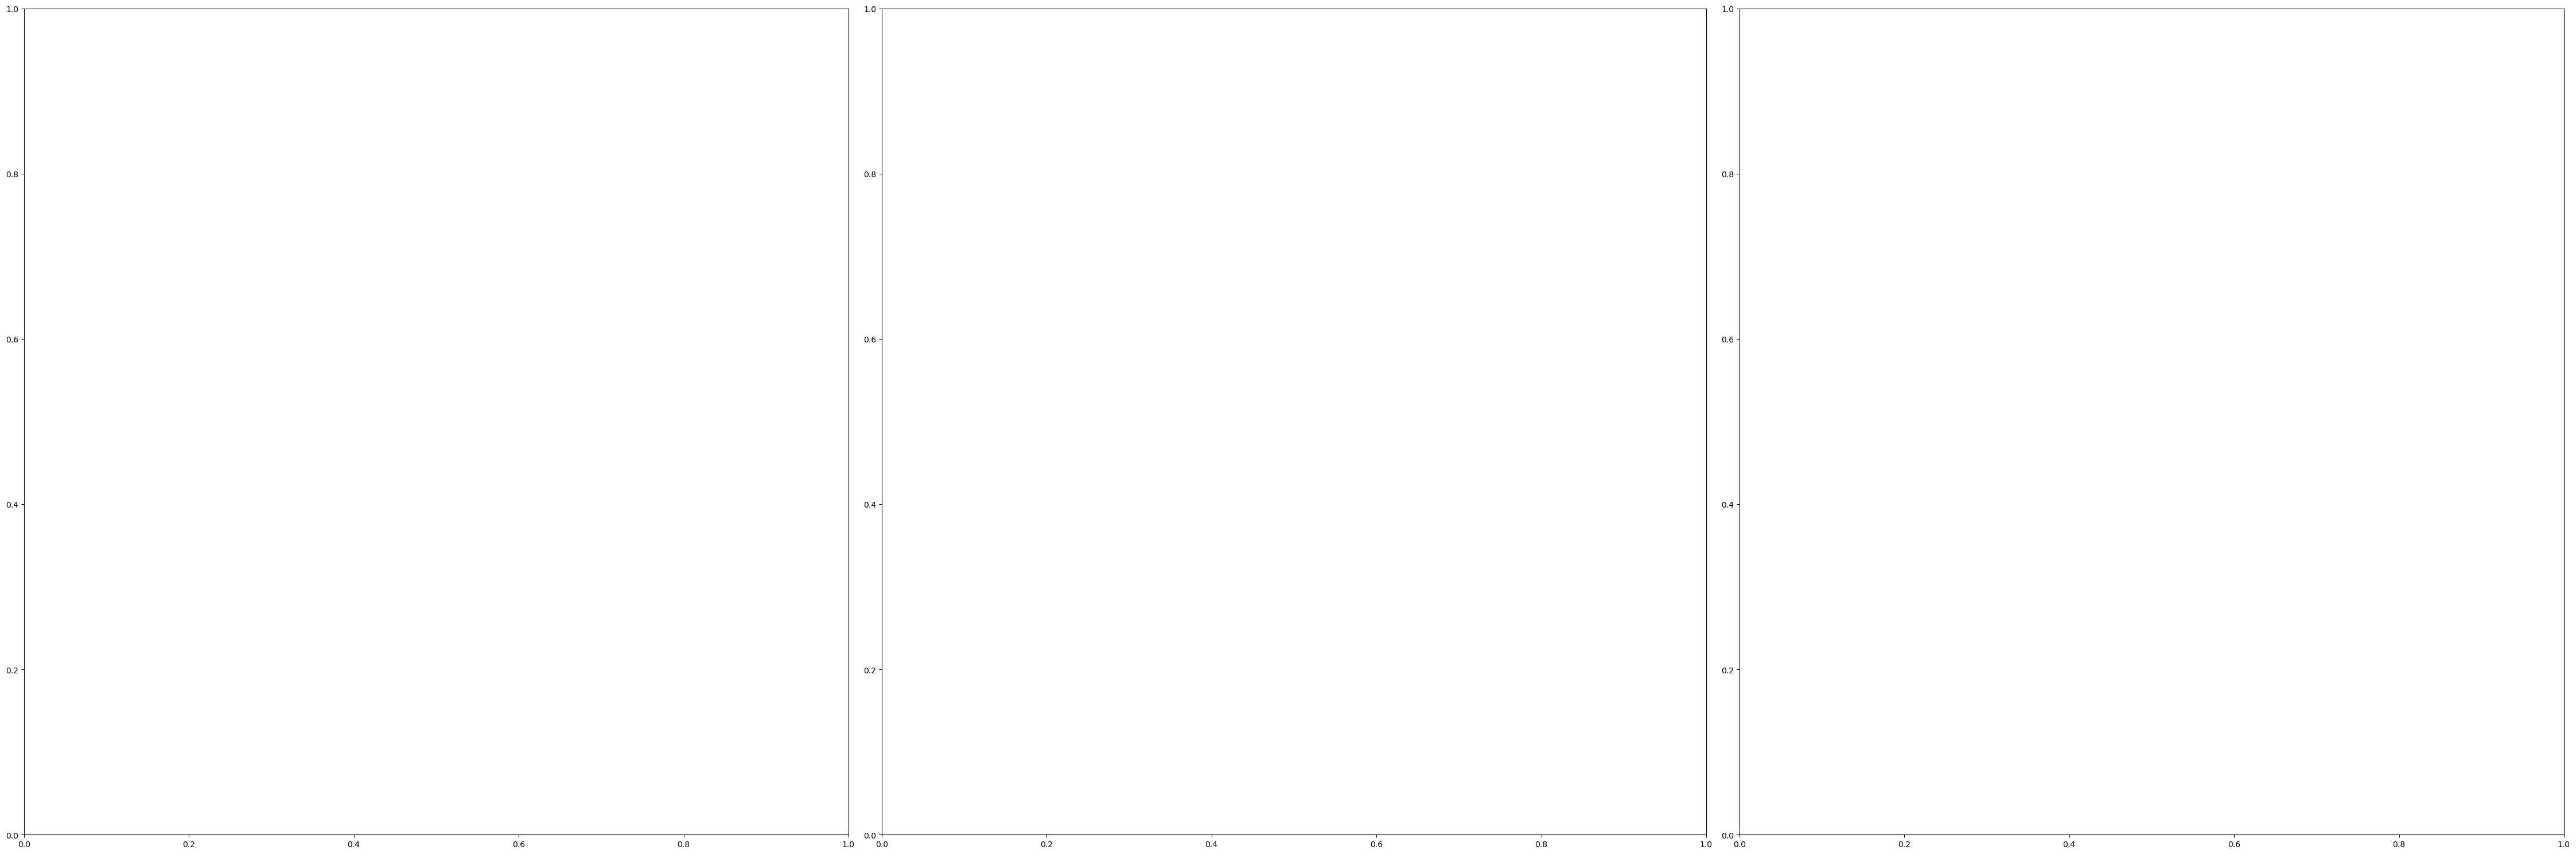

In [51]:
if database != 'basa':
    raise SystemExit("Different database")

# BASA DE LA MORA
fig, axes = plt.subplots(1,3,figsize=(45, 15))
fire_text = ['High fire', 'Low fire', 'Intermediate fire']

all_graphs_fg = []

for network in networks:
    graphs_fg = []
    for idx,(start,end) in enumerate(windows):
    # group the nodes by functional group and plot the functional groups as nodes, with size proportional to number of species in group and edges' weights proportional to number of links between groups
        start, end = windows[idx]
        ax = axes[idx]
        graph = network[idx].copy()

        # create a new graph with functional groups as nodes
        G_fg = nx.MultiDiGraph()
        # count number of species in each functional group
        fg_counts = {}
        for node in graph.nodes():
            fg = graph.nodes[node]['functional_group']
            if fg not in fg_counts:
                fg_counts[fg] = 0
            fg_counts[fg] += 1
        for fg, count in fg_counts.items():
            G_fg.add_node(fg, size=count)
        # add edges between functional groups

        edge_weights = {}
        for u, v, data in graph.edges(data=True):
            fg_u = graph.nodes[u]['functional_group']
            fg_v = graph.nodes[v]['functional_group']
            if fg_u != fg_v:
                if (fg_u, fg_v) not in edge_weights:
                    edge_weights[(fg_u, fg_v)] = (0, 0)
                if data['weight'] > 0:
                    edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0] + 1, edge_weights[(fg_u, fg_v)][1])
                elif data['weight'] < 0:
                    edge_weights[(fg_u, fg_v)] = (edge_weights[(fg_u, fg_v)][0], edge_weights[(fg_u, fg_v)][1] + 1)
        # add edges to the graph
        for (fg_u, fg_v), weight in edge_weights.items():
            G_fg.add_edge(fg_u, fg_v, color = '#0F4C5C', weight=weight[0]*1.5)#      np.sqrt(weight[0])*2.5)
            G_fg.add_edge(fg_u, fg_v, color = '#E36414',  weight=weight[1]*1.5)#      np.sqrt(weight[1]) *2.5)


        for u, v, key, weight in G_fg.copy().edges(data="weight", keys=True):
            # print(u, v, weight)
            if weight == 0:
                # print(f'Edge {u}->{v} has zero weight')
                G_fg.remove_edge(u,v,key)


        G = G_fg.copy()


        graphs_fg.append(G)

        continue
    
        # set initial positions where Grassland (node 0) is at the center, and the others around it in a circle

        labels = {  'temperate forest'     : 'Temperate\nforest',
                    'pinewoods'             : 'Pinewoods',
                    'shrubland'             : 'Shrubland',
                    'riverine community'   : 'Riverine\ncommunity',
                    'mediterranean'         : 'Mediterranean',
                    'pastureland'           : 'Pastureland',
                    'grassland'             : 'Grassland',
                    'rocky community': 'Rocky\ncommunity'}
        
        order = {   'Temperate\nforest'    :  1,
                    'Pinewoods'  : 2,
                    'Shrubland' : 3,
                    'Riverine\ncommunity'   : 4,
                    'Mediterranean' : 5,
                    'Rocky\ncommunity'  : 6,
                    'Pastureland' :   7
                    }
        
        N = len(G.nodes())
        initial_pos = {custom_community_index['grassland']: np.array([0.0, 0.0])}

        angle_step = 2 * np.pi / len(order)
        
        for node in G.nodes():
            og_label = custom_community_index_T[node]
            label = labels[og_label]
            if og_label != 'grassland':
                angle = angle_step * (order[label]-1)
                initial_pos[node] = np.array([np.cos(angle), np.sin(angle)])

        # pos = nx.spring_layout(G, weight = 'weight', seed = 1, pos = initial_pos, iterations=4)
        # # write pos to numpy file
        # np.save(f'plots-tests/pos_basa.npy', pos)
        pos = np.load(f'plots-tests/pos_basa.npy', allow_pickle=True).item()



        node_sizes = {n:G.nodes[n]['size']*1000 for n in G.nodes()}
        edge_groups = defaultdict(list)
        for u, v, data in G.edges(data=True):
            edge_groups[(u, v)].append(data)

        max_total_weight = max(sum(edge['weight'] for edge in edges) for edges in edge_groups.values())

        renderer = ax.figure.canvas.get_renderer()
        print(renderer.points_to_pixels(1.0)/72)
        community_colors_gen = sequential_custom_generator()
        # first get one per label, then assign them by their index
        community_colors = np.array([next(community_colors_gen) for n in range(len(labels))])
        community_colors = {n:community_colors[n] for n in G.nodes()}

        node_size_scale = 1/600000
        scale = 0.00085  # converts linewidth to offset in data space
        scale = 0.00112  # converts linewidth to offset in data space


        for (u, v), edges in sorted(edge_groups.items(), key=lambda uv_edges: sum(edge['weight'] for edge in uv_edges[1])):
            n = len(edges)
            total_width = sum(edge["weight"] for edge in edges)
            alpha = min(1.1 - np.exp(-4*total_width/max_total_weight), 1)

            if n == 1:
                data = edges[0]
                add_curved_edge(ax, pos, u, v, color=data["color"], weight=data["weight"],
                                rad=0.25, offset=0.0, node_radius_u=node_sizes[u] * node_size_scale,
                                node_radius_v=node_sizes[v]*node_size_scale, zorder=-1,
                                alpha = alpha)
            elif n == 2:
                # Multiple edges draw as touching parallels
                # Compute offsets so they are side-by-side, centered on the main line
                cumulative = 0
                sorted_edges = sorted(edges, key=lambda e: e["weight"])  # sort by width (optional aesthetic)
                w_0 = sorted_edges[0]["weight"]
                w_1 = sorted_edges[1]["weight"]
                offset = (w_0+w_1 / 1.0) * scale

                # set seed
                np.random.seed(0)
                rad = np.random.uniform(0.15,0.25)
                add_curved_edge(ax, pos, u, v, color=sorted_edges[0]["color"], weight=w_0, angle=0,
                                rad=rad, offset=-offset - 0.02, node_radius_u=node_sizes[u]*node_size_scale,
                                node_radius_v=node_sizes[v]*node_size_scale, arrowstyle='|/', zorder = -1,
                                alpha = alpha)
                
                # draw a white node to cover up the tip of the first arrow before drawing the second arrow
                # circle = plt.Circle(pos[u], 1.25*np.sqrt(node_sizes[u]*node_size_scale), color='white', zorder = 0)
                # ax.add_artist(circle)

                add_curved_edge(ax, pos, u, v, color=sorted_edges[1]["color"], weight=w_1,
                                rad=rad, offset=-0.02, node_radius_u=node_sizes[u] * node_size_scale,
                                node_radius_v=node_sizes[v] * node_size_scale, arrowstyle='|\\', zorder=-1,
                                alpha = alpha)

        nx.draw_networkx_nodes(G, pos, node_color=[community_colors[node] for node in G.nodes()], ax=ax, node_size = [node_sizes[n] for n in G.nodes()],
                            edgecolors="black", linewidths=4)
        # custom_community_index_T
        
        # set offset to label positions
        label_pos = {n: pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.08]) if pos[n][1] > 0.1 else
                        pos[n] + np.array([0,-np.sqrt(node_sizes[n])*0.001 - 0.08]) if pos[n][1] < -0.1 else 
                        pos[n] + np.array([0,np.sqrt(node_sizes[n])*0.001 + 0.08]) if pos[n][0] > 0.2 else
                        pos[n] + np.array([0,0.0]) for n in G.nodes()}
        
        texts = nx.draw_networkx_labels(G, pos = label_pos,
                                        ax=ax, labels={n:labels[custom_community_index_T[n]] for n in G.nodes()}, font_size = 30, font_color='black')
        
        # ADD WHITE BORDER TO THE TEXT ---------------------------------------------
        # for text in texts.values():
        #         text.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
        #                         path_effects.Normal()])
        # set limits to a square
        # ---------------------------------------------
        
        width = ax.get_xlim()[1] - ax.get_xlim()[0]
        height = ax.get_ylim()[1] - ax.get_ylim()[0]
        if width > height:
            plt.ylim(ax.get_ylim()[0] - (width - height) * 0.5, ax.get_ylim()[1] + (width - height) * 0.5)
        else:
            plt.xlim(ax.get_xlim()[0] - (height - width) * 0.5, ax.get_xlim()[1] + (height - width) * 0.5)
        # add some margin to the xlim and ylim
        margin = 0.16
        ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + 2*margin)
        ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
        print(ax.get_xlim(), ax.get_ylim())
        plt.axis("on")
        plt.tight_layout()


        # set title of the starting and ending years of the time window (set by abundances[species]['x'][start] and abundances[species]['x'][end])
        start_kabp = f'{-abundances[species_index_T_non_aq[0]]["x"][start]/1000 :.1f}'
        end_years = -abundances[species_index_T_non_aq[0]]["x"][end-1]
        end_kabp = f'{end_years/1000 :.1f} ka BP'
        print(end_years)
        if end_years < 0:
            start_kabp = f'{start_kabp} ka BP'
            end_kabp = 'present'
        ax.text(0.03, 0.95, f'{start_kabp} – {end_kabp}',
                transform=ax.transAxes, fontsize=35,
                verticalalignment='baseline', bbox=dict(boxstyle='round', facecolor='white', alpha=0.0))
        
        ax.set_title(f'Period {idx+1}: {fire_text[idx]}', size = 36)
        

    # --------------------------------------------------------------------------------------------------------------------------
        # now on the top right corner add the percentage of negative links (negative / negative+positive)
        negative_percentage = len([e for e in graph.edges(data=True) if e[2]['weight'] < 0]) / graph.number_of_edges()
        text_str =r'$f_{-}=' + f'{negative_percentage*100:.1f}' + r'\%$'
        ax.text(0.97, 0.95, text_str, fontsize=35,
                transform=ax.transAxes,
                va='baseline', horizontalalignment='right', clip_on=False)
    # --------------------------------------------------------------------------------------------------------------------------

        rectangle_colors = ["#9b031a","#FB990E","#e35412"]
        import matplotlib.patches as patches
        bottom_rect = patches.Rectangle(
            (0, 1), width=1.0, height=-0.08,
            transform=ax.transAxes,
            color=rectangle_colors[idx],
            zorder=-10,  # Ensure it sits behind the network and labels
            alpha=0.6
        )
        ax.add_patch(bottom_rect)

    all_graphs_fg.append(graphs_fg)

fig.tight_layout()
# fig.savefig(f'plots-tests/GC_functional_groups_{database}_{cond}.pdf', dpi=100)